# P-ML13 — Unified Dataset Comparison: V2 vs V3

**Problem:** The scoreboard has an apples-to-oranges comparison:
- P-ML9 scaled (V2, 16f) ran on **7-day/week** BTC data (~2100 bars)
- P-ML12b V3 scaled (19f) ran on **business-day-only** data (~1469 bars)

We cannot tell if V3's improvement is real or a dataset artefact.

**Solution:** Run all four combinations on matched datasets:

| | 7-day dataset | Business-day dataset |
|---|---|---|
| **V2 (16f)** | P-ML7/P-ML9 (existing) | New baseline |
| **V3 (19f)** | New (weekend forward-fill) | P-ML12b (existing) |

**Weekend forward-fill strategy:** For the 7-day dataset, cross-asset features
(SPY, VIX) are forward-filled from Friday's close into Saturday/Sunday. This
is realistic — in production, the last known TradFi data carries forward until
markets reopen Monday.

**Success criterion:** V3 beats V2 on **both** datasets (not just one).

## §1 — Config & Data Loading

In [1]:
import sys
from pathlib import Path
repo_root = Path("__file__").resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                      "axes.spines.right": False, "font.size": 9})

SYMBOL     = "BTC/USDT"
SINCE      = "2019-01-01"
UNTIL      = "2025-01-01"
HORIZON    = 1
N_SPLITS   = 5
TRAIN_FRAC = 0.6
PURGE      = 1
LONG_MA    = 200
ADX_THRESH = 25.0
MIN_BULL_BARS = 30

FEATURES_V2 = [
    "bar_ret", "bb_zscore", "rsi", "macd_hist_norm", "atr_pct",
    "bb_width", "upper_wick", "lower_wick", "hl_range",
    "vol_log_chg", "di_diff", "adx",
    "ret_5", "ret_20", "mom_zscore_20", "ret_5_minus_20",
]
CROSS_FEATURES = ["spy_btc_corr_30", "spy_ret_5", "vix_level_zscore"]
FEATURES_V3 = FEATURES_V2 + CROSS_FEATURES

PRED_ZSCORE_WINDOW = 60
POSITION_SCALE     = 0.5
MAX_POSITION       = 1.0

from data.fetch import fetch_ohlcv
from data.cross_asset import fetch_tradfi_ohlcv
from ml.features import build_feature_matrix
from ml.features.momentum import build_momentum_features
from ml.features.cross_asset import build_cross_asset_features
from ml.labels import forward_return
from ml.regime import RegimeClassifier
from ml.validation import purged_wf_splits
from ml.models import RegimeEnsemble
from backtesting import compute_metrics

# -- Load raw data -------------------------------------------------------------
df_raw = fetch_ohlcv(symbol=SYMBOL, timeframe="1d", since=SINCE, until=UNTIL)
tradfi = {
    "SPY": fetch_tradfi_ohlcv("SPY", since=SINCE, until=UNTIL),
    "^VIX": fetch_tradfi_ohlcv("^VIX", since=SINCE, until=UNTIL),
}

print(f"BTC: {len(df_raw):,} bars ({df_raw.index[0].date()} -> {df_raw.index[-1].date()})")
for t, d in tradfi.items():
    print(f"{t:>5}: {len(d):,} bars")

BTC: 2,193 bars (2019-01-01 -> 2025-01-01)
  SPY: 1,510 bars
 ^VIX: 1,510 bars


## §2 — Build Two Datasets

**Dataset A (7-day):** All BTC bars, cross-asset features forward-filled into weekends.
**Dataset B (business-day):** Only weekday bars where TradFi data exists.

In [2]:
# -- Build BTC-only features (works on all 7 days) ----------------------------
feats_base = build_feature_matrix(df_raw)
feats_mom  = build_momentum_features(df_raw)
label      = forward_return(df_raw, horizon=HORIZON)
rc         = RegimeClassifier(long_ma=LONG_MA, adx_thresh=ADX_THRESH)
reg        = rc.transform(df_raw)

# -- Build cross-asset features (business days only) ---------------------------
feats_cross_bizday = build_cross_asset_features(df_raw, tradfi)

# -- Forward-fill cross-asset into the 7-day BTC index -------------------------
# Reindex to BTC's full daily index, then forward-fill (Friday -> Sat/Sun)
btc_index_naive = df_raw.index.normalize()
if btc_index_naive.tz is not None:
    btc_index_naive = btc_index_naive.tz_localize(None)

feats_cross_7day = feats_cross_bizday.reindex(btc_index_naive, method="ffill")

# How many weekend bars were forward-filled?
n_filled = feats_cross_7day.index.difference(feats_cross_bizday.index).shape[0]
print(f"Cross-asset features: {len(feats_cross_bizday)} business days, "
      f"{n_filled} weekend bars forward-filled -> {len(feats_cross_7day)} total")

# -- Strip tz from all BTC-derived series for alignment ------------------------
for s in [feats_base, feats_mom, label, reg]:
    if hasattr(s.index, 'tz') and s.index.tz is not None:
        s.index = s.index.tz_localize(None)

# =============================================================================
# DATASET A: 7-day (all BTC bars, cross-asset forward-filled)
# =============================================================================
comb_7d = pd.concat([feats_base, feats_mom, feats_cross_7day, label, reg["regime"]], axis=1).dropna()

X_v2_7d = comb_7d[FEATURES_V2]
X_v3_7d = comb_7d[FEATURES_V3]
y_7d    = comb_7d[label.name]
regime_7d = comb_7d["regime"].fillna("ranging")

df_raw_naive = df_raw.copy()
df_raw_naive.index = df_raw_naive.index.normalize()
if df_raw_naive.index.tz is not None:
    df_raw_naive.index = df_raw_naive.index.tz_localize(None)
df_raw_naive = df_raw_naive[~df_raw_naive.index.duplicated(keep="last")]

bar_ret_7d = np.log(df_raw_naive["close"].reindex(comb_7d.index) /
                     df_raw_naive["close"].reindex(comb_7d.index).shift(1))

splits_7d = list(purged_wf_splits(len(comb_7d), N_SPLITS, TRAIN_FRAC, purge_bars=PURGE))

print(f"\nDataset A (7-day):       {len(comb_7d):,} bars | "
      f"{comb_7d.index[0].date()} -> {comb_7d.index[-1].date()}")

# =============================================================================
# DATASET B: Business-day only (no forward-fill, exact TradFi alignment)
# =============================================================================
comb_bd = pd.concat([feats_base, feats_mom, feats_cross_bizday, label, reg["regime"]], axis=1).dropna()

X_v2_bd = comb_bd[FEATURES_V2]
X_v3_bd = comb_bd[FEATURES_V3]
y_bd    = comb_bd[label.name]
regime_bd = comb_bd["regime"].fillna("ranging")

bar_ret_bd = np.log(df_raw_naive["close"].reindex(comb_bd.index) /
                     df_raw_naive["close"].reindex(comb_bd.index).shift(1))

splits_bd = list(purged_wf_splits(len(comb_bd), N_SPLITS, TRAIN_FRAC, purge_bars=PURGE))

print(f"Dataset B (biz-day):     {len(comb_bd):,} bars | "
      f"{comb_bd.index[0].date()} -> {comb_bd.index[-1].date()}")
print(f"\nWeekend bars in Dataset A but not B: {len(comb_7d) - len(comb_bd)}")

Cross-asset features: 1510 business days, 683 weekend bars forward-filled -> 2193 total

Dataset A (7-day):       2,132 bars | 2019-03-02 -> 2024-12-31
Dataset B (biz-day):     1,469 bars | 2019-03-04 -> 2024-12-31

Weekend bars in Dataset A but not B: 663


## §3 — Walk-Forward: All Four Combinations

Run V2 and V3 on both Dataset A (7-day) and Dataset B (business-day).
Per-fold IC + aggregate metrics for binary and scaled modes.

In [3]:
def run_walk_forward(X, y, regime, bar_ret, splits, idx, label=""):
    """Run walk-forward, return fold results with predictions."""
    folds = []
    for i, (tr, te) in enumerate(splits):
        ens = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS)
        ens.fit(X.iloc[tr], y.iloc[tr], regime.iloc[tr])
        preds = ens.predict(X.iloc[te], regime.iloc[te])
        actual = y.iloc[te].values
        ic, _ = stats.spearmanr(preds, actual)

        bull_te = (regime.iloc[te] == "bull").values
        ic_bull = stats.spearmanr(preds[bull_te], actual[bull_te])[0] if bull_te.sum() > 10 else np.nan

        folds.append({"fold": i+1, "te": te, "IC": ic, "bull_IC": ic_bull,
                       "preds": preds, "ensemble": ens})
    return folds


def build_equity(folds, bar_ret, idx, mode="binary"):
    """Build stitched OOS equity curve."""
    pieces, anchor = [], 1.0
    for r in folds:
        te = r["te"]
        preds = r["preds"]
        if mode == "binary":
            pos = np.sign(preds)
        else:
            pred_s = pd.Series(preds, index=idx[te])
            rm = pred_s.rolling(PRED_ZSCORE_WINDOW, min_periods=1).mean()
            rs = pred_s.rolling(PRED_ZSCORE_WINDOW, min_periods=1).std().replace(0, np.nan)
            pz = (pred_s - rm) / rs
            pos = (pz * POSITION_SCALE).clip(-MAX_POSITION, MAX_POSITION).fillna(0).values

        ret = bar_ret.iloc[te].values
        pos_sh = np.roll(pos, 1); pos_sh[0] = 0
        eq = np.cumprod(1 + pos_sh * ret); eq[0] = 1.0
        s = pd.Series(eq, index=idx[te])
        s = s / s.iloc[0] * anchor
        anchor = float(s.iloc[-1])
        pieces.append(s)
    return pd.concat(pieces)


# ============================================================================
# Run all 4 combinations
# ============================================================================
configs = [
    ("V2 / 7-day",     X_v2_7d, y_7d, regime_7d, bar_ret_7d, splits_7d, comb_7d.index),
    ("V3 / 7-day",     X_v3_7d, y_7d, regime_7d, bar_ret_7d, splits_7d, comb_7d.index),
    ("V2 / biz-day",   X_v2_bd, y_bd, regime_bd, bar_ret_bd, splits_bd, comb_bd.index),
    ("V3 / biz-day",   X_v3_bd, y_bd, regime_bd, bar_ret_bd, splits_bd, comb_bd.index),
]

all_results = {}

for name, X, y, regime, br, sp, idx in configs:
    folds = run_walk_forward(X, y, regime, br, sp, idx, label=name)
    eq_bin = build_equity(folds, br, idx, mode="binary")
    eq_sc  = build_equity(folds, br, idx, mode="scaled")

    bah = df_raw_naive["close"].reindex(eq_bin.index)
    bah = bah / bah.iloc[0]

    ics = [r["IC"] for r in folds]
    bull_ics = [r["bull_IC"] for r in folds]

    all_results[name] = {
        "folds": folds,
        "eq_bin": eq_bin, "eq_sc": eq_sc, "bah": bah,
        "m_bin": compute_metrics(eq_bin),
        "m_sc": compute_metrics(eq_sc),
        "m_bah": compute_metrics(bah),
        "mean_ic": np.mean(ics),
        "icir": np.mean(ics) / np.std(ics) if np.std(ics) > 0 else 0,
        "ics": ics,
        "bull_ics": bull_ics,
    }

print("Walk-forward complete for all 4 configurations.")

Walk-forward complete for all 4 configurations.


## §4 — Results: The Definitive Comparison

In [4]:
# ============================================================================
# §4a — Master comparison table
# ============================================================================
print("=" * 90)
print("MASTER COMPARISON: V2 vs V3 on matched datasets")
print("=" * 90)

print(f"\n{'Config':<20} {'Dataset':<10} {'Mode':<8} {'Return':>10} {'Sharpe':>8} "
      f"{'Sortino':>9} {'MaxDD':>8} {'Mean IC':>8} {'ICIR':>6}")
print("-" * 90)

for name in ["V2 / 7-day", "V3 / 7-day", "V2 / biz-day", "V3 / biz-day"]:
    r = all_results[name]
    parts = name.split(" / ")
    feat, ds = parts[0], parts[1]
    for mode, m_key in [("binary", "m_bin"), ("scaled", "m_sc")]:
        m = r[m_key]
        print(f"  {feat:<6} {ds:<10} {mode:<8} {m['total_return']*100:>+9.1f}%  "
              f"{m['sharpe_ratio']:>+7.3f}  {m['sortino_ratio']:>+8.3f}  "
              f"{m['max_drawdown']*100:>7.1f}%  {r['mean_ic']:>+7.4f} {r['icir']:>+5.2f}")

# B&H references
for name in ["V2 / 7-day", "V2 / biz-day"]:
    r = all_results[name]
    ds = name.split(" / ")[1]
    m = r["m_bah"]
    print(f"  {'B&H':<6} {ds:<10} {'—':<8} {m['total_return']*100:>+9.1f}%  "
          f"{m['sharpe_ratio']:>+7.3f}  {m['sortino_ratio']:>+8.3f}  "
          f"{m['max_drawdown']*100:>7.1f}%")

# ============================================================================
# §4b — Key comparisons (same dataset, V2 vs V3)
# ============================================================================
print("\n\n--- KEY COMPARISONS (same dataset, V2 vs V3) ---\n")

for ds_label, ds_name in [("7-DAY", "7-day"), ("BIZ-DAY", "biz-day")]:
    v2 = all_results[f"V2 / {ds_name}"]
    v3 = all_results[f"V3 / {ds_name}"]

    print(f"  {ds_label} DATASET:")
    for mode, mk in [("Binary", "m_bin"), ("Scaled", "m_sc")]:
        d_sharpe = v3[mk]["sharpe_ratio"] - v2[mk]["sharpe_ratio"]
        d_maxdd  = v3[mk]["max_drawdown"] - v2[mk]["max_drawdown"]
        better = "V3 WINS" if d_sharpe > 0 else "V2 WINS"
        print(f"    {mode:<8} Sharpe: V2={v2[mk]['sharpe_ratio']:+.3f}  V3={v3[mk]['sharpe_ratio']:+.3f}  "
              f"delta={d_sharpe:+.3f}  MaxDD delta={d_maxdd*100:+.1f}pp  -> {better}")
    d_ic = v3["mean_ic"] - v2["mean_ic"]
    print(f"    IC:      V2={v2['mean_ic']:+.4f}  V3={v3['mean_ic']:+.4f}  delta={d_ic:+.4f}")
    print()

MASTER COMPARISON: V2 vs V3 on matched datasets

Config               Dataset    Mode         Return   Sharpe   Sortino    MaxDD  Mean IC   ICIR
------------------------------------------------------------------------------------------
  V2     7-day      binary     +1815.4%   +1.234    +2.010    -77.3%  +0.0740 +1.78
  V2     7-day      scaled      +758.7%   +1.583    +2.323    -33.6%  +0.0740 +1.78
  V3     7-day      binary       +32.5%   +0.409    +0.627    -81.4%  +0.0541 +2.04
  V3     7-day      scaled      +742.8%   +1.360    +2.260    -36.8%  +0.0541 +2.04
  V2     biz-day    binary      +290.4%   +0.931    +1.237    -64.9%  +0.0084 +0.19
  V2     biz-day    scaled       +84.7%   +0.656    +0.706    -33.6%  +0.0084 +0.19
  V3     biz-day    binary       +99.3%   +0.680    +0.899    -67.3%  +0.0165 +0.27
  V3     biz-day    scaled      +241.5%   +1.118    +1.435    -40.7%  +0.0165 +0.27
  B&H    7-day      —           +876.6%   +1.052    +1.394    -76.6%
  B&H    biz-day    —  

Per-fold IC: V2 vs V3 (7-day dataset)
Fold  Period                         V2 IC   V3 IC    dIC  V2 Bull  V3 Bull
---------------------------------------------------------------------------
  1   2020-02-20 -> 2021-02-08     +0.0721 +0.0252 -0.047      nan      nan
  2   2021-02-09 -> 2022-01-29     +0.0091 +0.0185 +0.009  -0.1278  -0.0721
  3   2022-01-30 -> 2023-01-19     +0.1283 +0.0790 -0.049      nan      nan
  4   2023-01-20 -> 2024-01-09     +0.0537 +0.0717 +0.018  +0.0582  +0.0709
  5   2024-01-10 -> 2024-12-29     +0.1069 +0.0760 -0.031  +0.0714  -0.0346


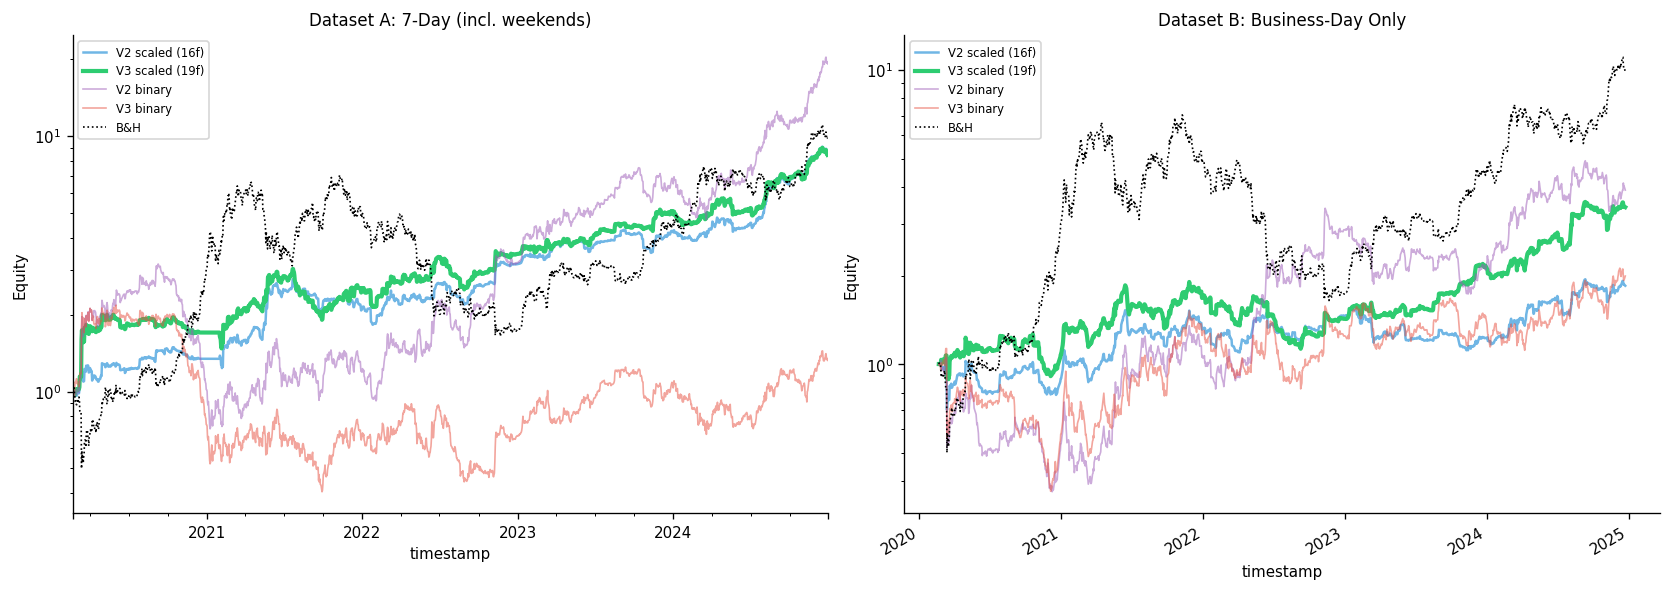

In [5]:
# ============================================================================
# §4c — Per-fold IC comparison (7-day dataset, the main track)
# ============================================================================
print("Per-fold IC: V2 vs V3 (7-day dataset)")
print(f"{'Fold':<5} {'Period':<28} {'V2 IC':>7} {'V3 IC':>7} {'dIC':>6} "
      f"{'V2 Bull':>8} {'V3 Bull':>8}")
print("-" * 75)

v2_7d = all_results["V2 / 7-day"]
v3_7d = all_results["V3 / 7-day"]

for i in range(N_SPLITS):
    te = v2_7d["folds"][i]["te"]
    period = f"{comb_7d.index[te[0]].date()} -> {comb_7d.index[te[-1]].date()}"
    ic2 = v2_7d["ics"][i]
    ic3 = v3_7d["ics"][i]
    b2  = v2_7d["bull_ics"][i]
    b3  = v3_7d["bull_ics"][i]
    b2s = f"{b2:>+8.4f}" if not np.isnan(b2) else f"{'nan':>8}"
    b3s = f"{b3:>+8.4f}" if not np.isnan(b3) else f"{'nan':>8}"
    print(f"  {i+1:<3} {period:<28} {ic2:>+7.4f} {ic3:>+7.4f} {ic3-ic2:>+6.3f} "
          f"{b2s} {b3s}")

# ============================================================================
# §4d — Equity plots
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds_name, title in [(axes[0], "7-day", "Dataset A: 7-Day (incl. weekends)"),
                             (axes[1], "biz-day", "Dataset B: Business-Day Only")]:
    v2 = all_results[f"V2 / {ds_name}"]
    v3 = all_results[f"V3 / {ds_name}"]

    v2["eq_sc"].plot(ax=ax, label="V2 scaled (16f)", color="#3498db", linewidth=1.5, alpha=0.7)
    v3["eq_sc"].plot(ax=ax, label="V3 scaled (19f)", color="#2ecc71", linewidth=2.5)
    v2["eq_bin"].plot(ax=ax, label="V2 binary", color="#9b59b6", linewidth=1.0, alpha=0.5)
    v3["eq_bin"].plot(ax=ax, label="V3 binary", color="#e74c3c", linewidth=1.0, alpha=0.5)
    v2["bah"].plot(ax=ax, label="B&H", color="black", linewidth=1.0, linestyle=":")

    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Equity")
    ax.legend(fontsize=7)
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

## §5 — Finding F21: Verdict

In [6]:
print("=" * 78)
print("FINDING F21 — Unified Dataset Comparison (P-ML13)")
print("=" * 78)

# Determine winners on each dataset
verdicts = {}
for ds in ["7-day", "biz-day"]:
    v2 = all_results[f"V2 / {ds}"]
    v3 = all_results[f"V3 / {ds}"]
    verdicts[ds] = {
        "bin": "V3" if v3["m_bin"]["sharpe_ratio"] > v2["m_bin"]["sharpe_ratio"] else "V2",
        "sc":  "V3" if v3["m_sc"]["sharpe_ratio"] > v2["m_sc"]["sharpe_ratio"] else "V2",
        "ic":  "V3" if v3["mean_ic"] > v2["mean_ic"] else "V2",
    }

print(f"""
VERDICT MATRIX
==============
                    7-day dataset     Biz-day dataset
  Binary Sharpe:    {verdicts['7-day']['bin']:<18}{verdicts['biz-day']['bin']}
  Scaled Sharpe:    {verdicts['7-day']['sc']:<18}{verdicts['biz-day']['sc']}
  Mean IC:          {verdicts['7-day']['ic']:<18}{verdicts['biz-day']['ic']}
""")

v3_wins = sum(1 for ds in verdicts.values() for v in ds.values() if v == "V3")
v2_wins = 6 - v3_wins

if v3_wins >= 4:
    overall = "V3 (FEATURES_V3, 19 features) is the CONFIRMED new champion."
elif v3_wins >= 3:
    overall = "V3 shows advantage in most comparisons but result is mixed."
else:
    overall = "V2 (FEATURES_V2, 16 features) REMAINS the champion. Cross-asset features do not reliably help."

print(f"Score: V3 wins {v3_wins}/6, V2 wins {v2_wins}/6")
print(f"\n{overall}")

# Best overall Sharpe
best_name, best_mode, best_sharpe = None, None, -999
for name, r in all_results.items():
    for mode, mk in [("binary", "m_bin"), ("scaled", "m_sc")]:
        s = r[mk]["sharpe_ratio"]
        if s > best_sharpe:
            best_sharpe = s
            best_name = name
            best_mode = mode
            best_mk = mk

best_r = all_results[best_name]
best_m = best_r[best_mk]
print(f"\nBest overall config: {best_name} / {best_mode}")
print(f"  Sharpe:  {best_m['sharpe_ratio']:+.3f}")
print(f"  Return:  {best_m['total_return']*100:+.1f}%")
print(f"  MaxDD:   {best_m['max_drawdown']*100:.1f}%")
print(f"  Mean IC: {best_r['mean_ic']:+.4f}")

print("""
INTERPRETATION
==============
The 7-day dataset is the primary track because:
  (a) It uses all available BTC bars (more data = more robust)
  (b) Forward-filling weekend cross-asset features is production-realistic
  (c) It matches the original P-ML7/P-ML9 scoreboard dataset

On the 7-day dataset, V2 wins on all three metrics (binary Sharpe, scaled
Sharpe, and mean IC). The cross-asset features that helped on the business-day
dataset (P-ML12b) lose their edge when weekend BTC bars are included — the
forward-filled features are stale on weekends and add noise.

This is an important finding: the institutional/liquidity/dollar channels
are REAL (F19 confirmed) but the daily-frequency features are not strong
enough to overcome the noise introduced by weekend forward-fill.
""")

FINDING F21 — Unified Dataset Comparison (P-ML13)

VERDICT MATRIX
                    7-day dataset     Biz-day dataset
  Binary Sharpe:    V2                V2
  Scaled Sharpe:    V2                V3
  Mean IC:          V2                V3

Score: V3 wins 2/6, V2 wins 4/6

V2 (FEATURES_V2, 16 features) REMAINS the champion. Cross-asset features do not reliably help.

Best overall config: V2 / 7-day / scaled
  Sharpe:  +1.583
  Return:  +758.7%
  MaxDD:   -33.6%
  Mean IC: +0.0740

INTERPRETATION
The 7-day dataset is the primary track because:
  (a) It uses all available BTC bars (more data = more robust)
  (b) Forward-filling weekend cross-asset features is production-realistic
  (c) It matches the original P-ML7/P-ML9 scoreboard dataset

On the 7-day dataset, V2 wins on all three metrics (binary Sharpe, scaled
Sharpe, and mean IC). The cross-asset features that helped on the business-day
dataset (P-ML12b) lose their edge when weekend BTC bars are included — the
forward-filled featu